# Simple example of usage

In [18]:
import os
import sys
from copy import copy

sys.path.append('..')
import PhyloTreeClustering # local module
from PhyloTreeClustering.PhyloTreeClustering import PhyloTreeClustering
from PhyloTreeClustering.medicc_functions import import_tree, plot_tree
from PhyloTreeClustering.calculate_pdm import calculate_pdm_from_tree


In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Small Gao Tree

In [3]:
results_dir = '../example_data' 
tree_loc = os.path.join(results_dir, 'Gao_2016_12_final_tree.new') #tree path
medicc_tree = import_tree(tree_loc, 'diploid') #import tree
pdm_tree = calculate_pdm_from_tree(medicc_tree, [clade.name for clade in medicc_tree.get_terminals()]) #pairwise distance matrix from tree with node names extracted from get.terimals()

In [4]:
# relative dist matrix with division
relative_dist_matrix = copy(pdm_tree)
leave_mean_dists = pdm_tree.mean()
relative_dist_matrix = relative_dist_matrix.divide(leave_mean_dists, axis= 'columns')
relative_dist_matrix = relative_dist_matrix.divide(leave_mean_dists, axis= 'index')

### 3 equivalent ways of initializing PhyloTreeClustering

In [8]:
example_clus = PhyloTreeClustering(tree_file_path= '../example_data/Gao_2016_12_final_tree.new')

In [9]:
example_clus = PhyloTreeClustering(tree= medicc_tree, dist_matrix= relative_dist_matrix, CH_matrix= pdm_tree)

In [8]:
example_clus = PhyloTreeClustering(tree = medicc_tree)

### Running and plotting the results

In [10]:
example_clus.run()

array([<Axes: title={'center': 'cluster_number = 3\nth = 0.006\nth range = [0.0, 0.014]'}, xlabel='branch length', ylabel='taxa'>,
       <Axes: title={'center': 'Calinski Harabasz score = 12.82'}, xlabel='branch length', ylabel='taxa'>],
      dtype=object)

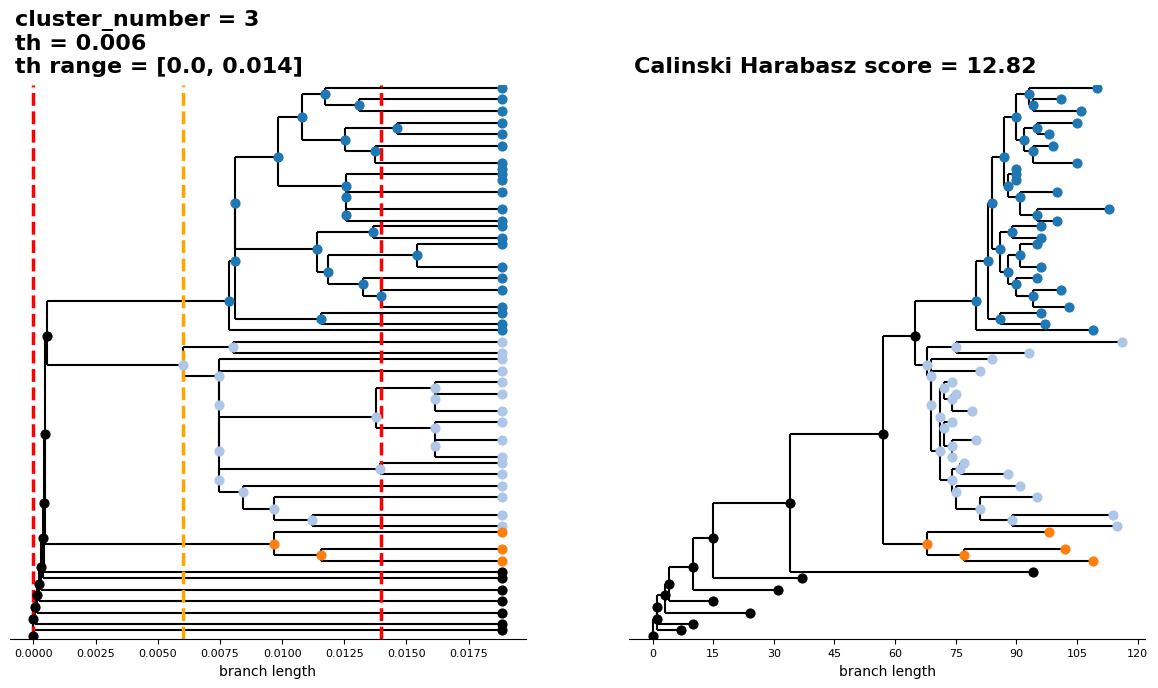

In [13]:
example_clus.plot_summary()

In [31]:
#import pandas as pd
example_clus.sample_labels()
#df = pd.DataFrame(example_clus.sample_labels(), columns = ['Sample','Labels'])

array([['SRR090209', '0'],
       ['SRR090129', '0'],
       ['SRR090211', '0'],
       ['SRR090126', '0'],
       ['SRR090130', '0'],
       ['SRR090144', '0'],
       ['SRR090155', '0'],
       ['SRR089748', '0'],
       ['SRR090135', '0'],
       ['SRR090213', '0'],
       ['SRR089817', '0'],
       ['SRR090142', '0'],
       ['SRR090156', '0'],
       ['SRR090212', '0'],
       ['SRR090131', '0'],
       ['SRR090133', '0'],
       ['SRR090158', '0'],
       ['SRR090198', '0'],
       ['SRR090206', '0'],
       ['SRR090159', '0'],
       ['SRR090210', '0'],
       ['SRR089757', '0'],
       ['SRR089701', '1'],
       ['SRR089702', '1'],
       ['SRR089698', '1'],
       ['SRR089696', '1'],
       ['SRR089662', '1'],
       ['SRR089659', '1'],
       ['SRR089664', '1'],
       ['SRR089665', '1'],
       ['SRR089666', '1'],
       ['SRR089694', '1'],
       ['SRR089646', '1'],
       ['SRR089663', '1'],
       ['SRR089695', '1'],
       ['SRR089697', '1'],
       ['SRR089699', '1'],
 

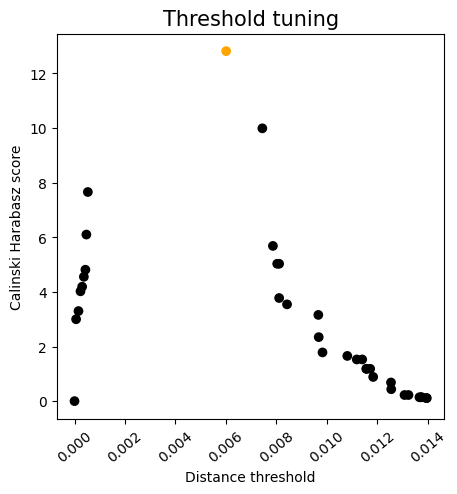

<Axes: title={'center': 'Threshold tuning'}, xlabel='Distance threshold', ylabel='Calinski Harabasz score'>

In [11]:
example_clus.plot_th_score()

## Big Minussi Tree

In [20]:
results_dir = '../example_data'
tree_loc = os.path.join(results_dir, 'TN20_majmin_final_tree.new')
big_medicc_tree = import_tree(tree_loc, 'diploid')
big_pdm_tree = calculate_pdm_from_tree(big_medicc_tree, [clade.name for clade in big_medicc_tree.get_terminals()])

In [22]:
# relative dist matrix with division
big_relative_dist_matrix = copy(big_pdm_tree)
leave_mean_dists = big_pdm_tree.mean()
big_relative_dist_matrix = big_relative_dist_matrix.divide(leave_mean_dists, axis= 'columns')
big_relative_dist_matrix = big_relative_dist_matrix.divide(leave_mean_dists, axis= 'index')

In [23]:
big_example_clus = PhyloTreeClustering(tree= big_medicc_tree, dist_matrix= big_relative_dist_matrix, CH_matrix= big_pdm_tree)

In [17]:
big_example_clus = PhyloTreeClustering(tree= big_medicc_tree)

In [24]:
big_example_clus.run()

array([<Axes: title={'center': 'cluster_number = 16\nth = 0.004\nth range = [0.0, 0.006]'}, xlabel='branch length', ylabel='taxa'>,
       <Axes: title={'center': 'Calinski Harabasz score = 352.276'}, xlabel='branch length', ylabel='taxa'>],
      dtype=object)

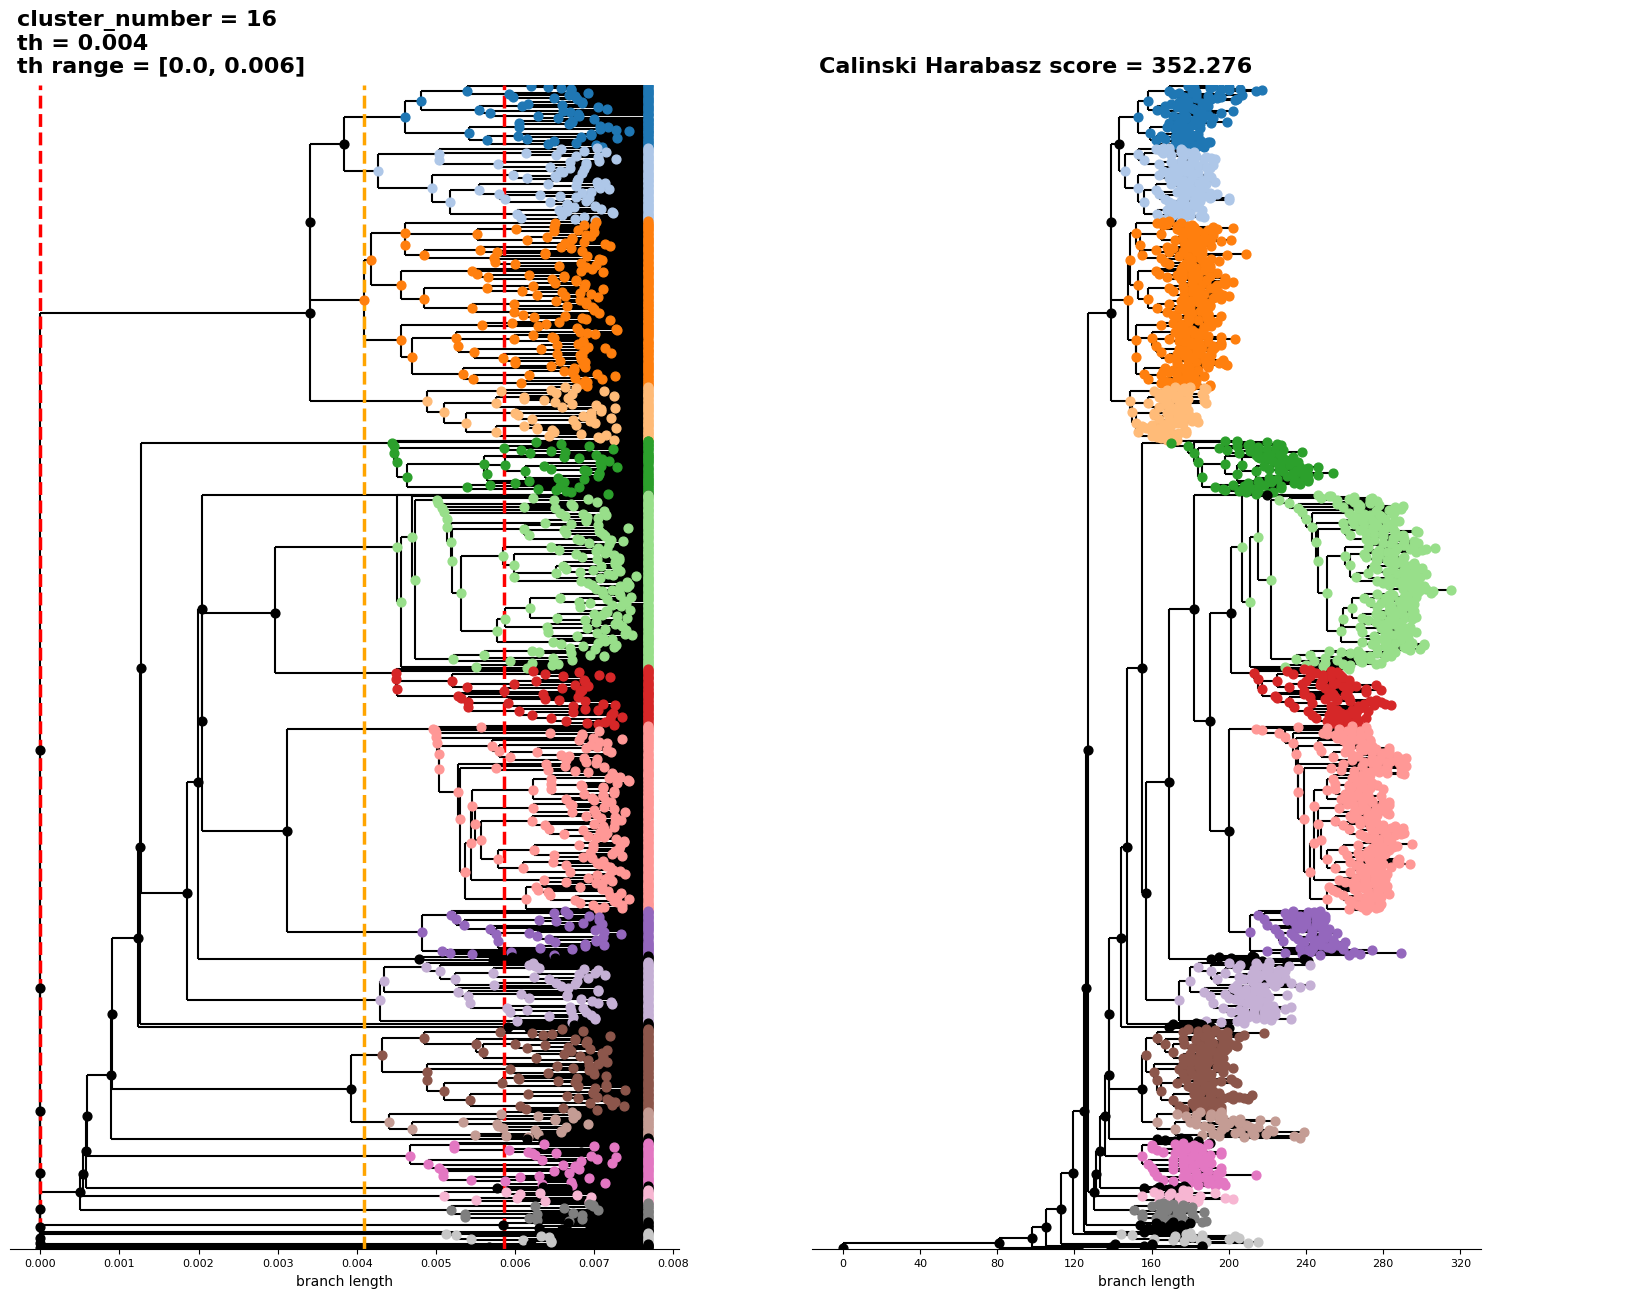

In [19]:
big_example_clus.plot_summary()

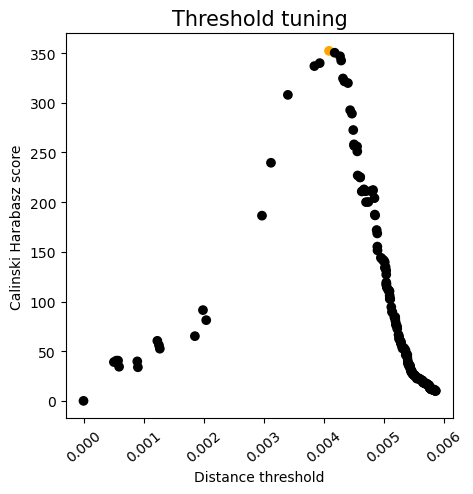

<Axes: title={'center': 'Threshold tuning'}, xlabel='Distance threshold', ylabel='Calinski Harabasz score'>

In [17]:
big_example_clus.plot_th_score()

In [12]:
import numpy as np
from itertools import combinations #It returns r-length tuples in sorted order with no repeated elements
import pandas as pd

In [15]:
tree = medicc_tree
sample_labels = [clade.name for clade in medicc_tree.get_terminals()]


In [32]:
depths = {k.name: v for k, v in tree.depths().items()}
dm = np.zeros((len(sample_labels), len(sample_labels)))

paths = {t: np.array([x.name for x in tree.get_path(t)][:-1]) for t in sample_labels}

for i, j in combinations(np.arange(len(sample_labels)), r=2):
  s1 = sample_labels[i]
  s2 = sample_labels[j]

  if s1 == 'diploid':
    cur_dist = depths[s2]
  elif s2 == 'diploid':
    cur_dist = depths[s1]
  else:
    cma = paths[s1][np.in1d(paths[s1], paths[s2])][-1]
    cur_dist = depths[s1] + depths[s2] - 2* depths[cma]
  dm[i, j] = cur_dist
  dm[j, i] = cur_dist    

dm = pd.DataFrame(dm, index = sample_labels, columns = sample_labels)
dm = dm.astype(float)

    #return dm

'internal_1'

In [34]:
example_clus.labels_

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1]

In [ ]:

 def score_within_cluster_dispersion(self, Cluster):
        """Returns the trace of the WGk matrix for a specific cluster. It's the same as score_total_sum_square but computed with WGk matrix' coefficients.

        :param Cluster: Cluster label name.

        :returns: float."""
        if not (Cluster in self.labels_clusters):
            raise AttributeError(
                'A such cluster name "' + Cluster + '" isn\'t found in dataframe\'s columns. Here are the available columns : ' + str(
                    list(self.data_features.columns.values)))
        else:
            return self.data_clusters[Cluster].shape[0] * (self.data_clusters[Cluster].var(ddof=0, axis=0)).sum()
    def scatter_matrix_between_group_BG(self):
        """Return the matrix composed with the dispersion between centroids and the barycenter.

        :returns: a Pandas dataframe. """
        B = pd.DataFrame()
        for Cluster in self.labels_clusters:
            B = B.append(np.sqrt(self.num_observation_for_specific_cluster[Cluster]) * (
                        self.data_centroids[Cluster] - self.data_barycenter), ignore_index=True)
        return B.T.dot(B)
   def score_pooled_within_cluster_dispersion(self):
        """Returns the sum of score_within_cluster_dispersion for each cluster.

        :returns: float. """
        return np.sum([self.score_within_cluster_dispersion(Cluster) for Cluster in self.labels_clusters])

  def score_between_group_dispersion(self):
        """Returns the between group dispersion, can also be seen as the trace of the between group matrix.

        :returns: float. """
        return np.trace(self.scatter_matrix_between_group_BG())

 def score_index_calinski_harabasz(self):
        """Defined in the first reference.

        :returns: float.
        """
        K = self.num_clusters
        WGSS_red = self.score_pooled_within_cluster_dispersion() / (self.num_observations - K)
        BGSS_red = self.score_between_group_dispersion() / (K - 1)
        return BGSS_red / WGSS_red

In [32]:
dir(example_clus)

['CH_matrix',
 'CH_scores',
 'N',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'adjust_branch_length_tree',
 'all_CH_labels',
 'all_names',
 'best_CH',
 'best_th',
 'calculate_dendro_dists',
 'child_parent_dist',
 'clus_number',
 'cluster',
 'cluster_clades',
 'color_dict',
 'compute_dist_matrix',
 'dendro_dists',
 'dendro_tree',
 'dist_matrix',
 'dist_matrix_df',
 'dist_type',
 'first_CH_scores',
 'first_best_CH',
 'index_to_name',
 'init_CH_matrix',
 'init_dist_matrix',
 'init_min_size_clus',
 'init_n_diff_th',
 'init_name_to_clade',
 'init_name_to_index',
 'init_parent',
 'init_th',
 'init_tree',
 'label_colors_color_dict',
 'labels_',
 'leave_na

In [55]:
kmedoids.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [51]:
from PhyloTreeClustering.calinski_harabasz import calinski_harabasz_score

calinski_harabasz_score(dm, kmedoids.labels_)

69.83111777299737

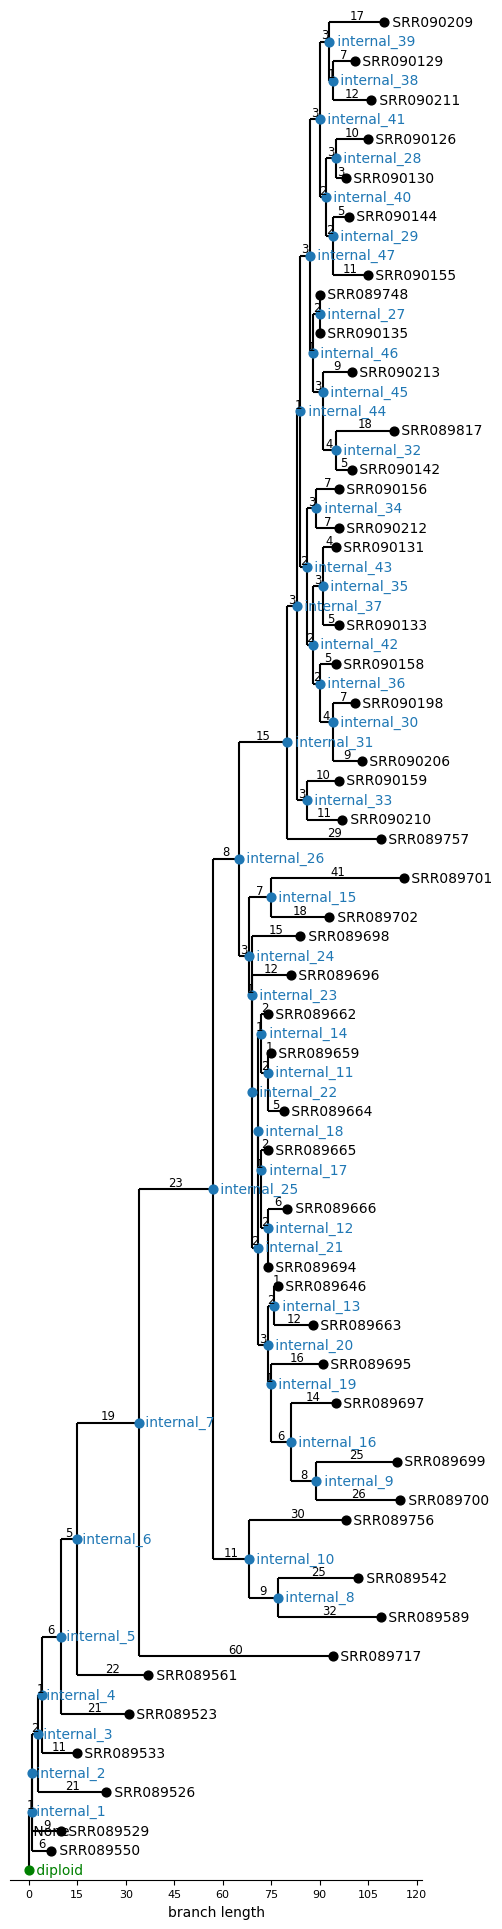

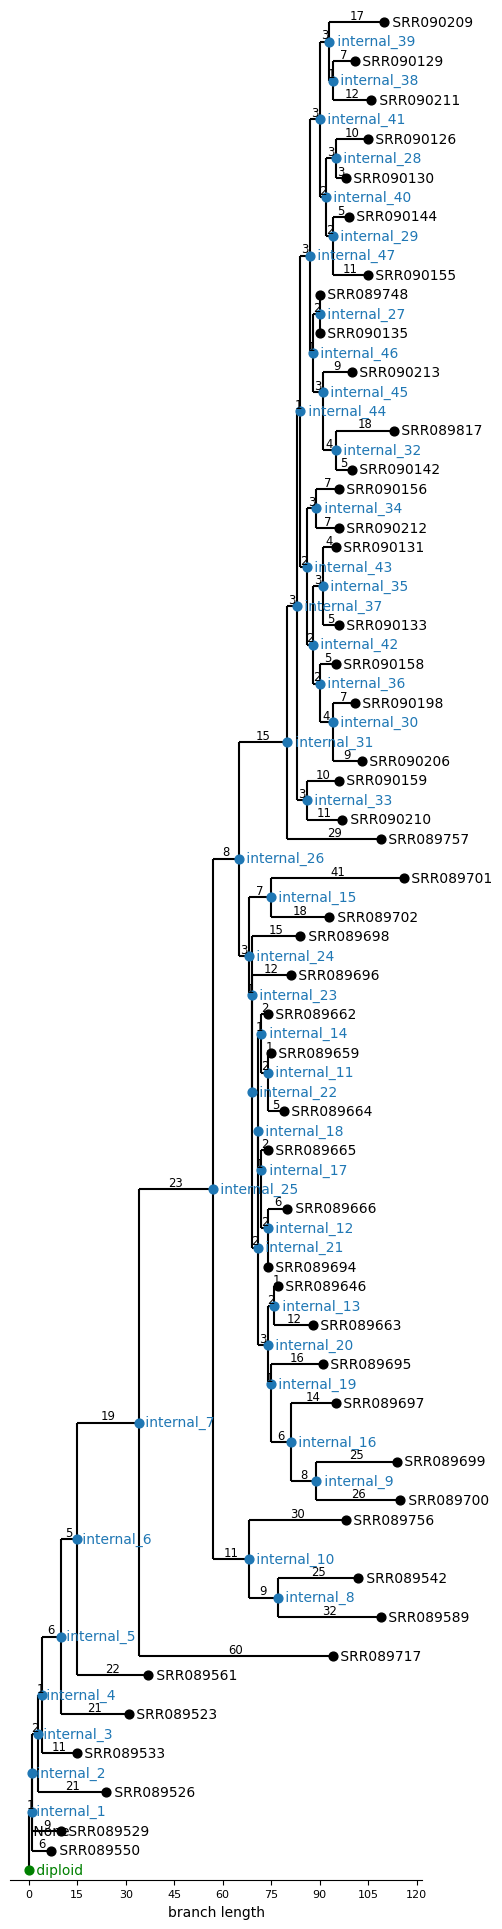

In [6]:
plot_tree(medicc_tree)

'           SRR090209  SRR090129  SRR090211  SRR090126  SRR090130  SRR090144  \\\nSRR090209        0.0       25.0       30.0       35.0       28.0       29.0   \nSRR090129       25.0        0.0       19.0       26.0       19.0       20.0   \nSRR090211       30.0       19.0        0.0       31.0       24.0       25.0   \nSRR090126       35.0       26.0       31.0        0.0       13.0       20.0   \nSRR090130       28.0       19.0       24.0       13.0        0.0       13.0   \nSRR090144       29.0       20.0       25.0       20.0       13.0        0.0   \nSRR090155       35.0       26.0       31.0       26.0       19.0       16.0   \nSRR089748       26.0       17.0       22.0       21.0       14.0       15.0   \nSRR090135       26.0       17.0       22.0       21.0       14.0       15.0   \nSRR090213       36.0       27.0       32.0       31.0       24.0       25.0   \nSRR089817       49.0       40.0       45.0       44.0       37.0       38.0   \nSRR090142       36.0       27.0       

In [29]:
pdm_tree.to_csv("CH_matrix.csv")

In [27]:
big_df.to_csv("big_labels.csv")

In [26]:
big_df = pd.DataFrame(big_example_clus.sample_labels(), columns = ['Sample','Labels'])

In [25]:
big_relative_dist_matrix.to_csv("big_pdm.csv")
